Objetivo- crear un modelo que ayude a predecir si se va a ver una pelicula o no. Al crear este modelo de ML podremos crear un MVP que recomiende películas. Debido a que el modelo sólo se alimentará de nuestros datos tratados, sólo usaremos de los datos del ETL para el EDA. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_EDA= pd.read_csv(
    r"C:\Users\param\OneDrive\Escritorio\Programacion\Soy Henry\Proyecto individual 1\DATASETS\df_data_EDA")
    

Examinemos todos los atributos de la data.

In [2]:
print(df_EDA.columns)
# Duracion/genero/año(si es moderno o clasico)/popularidad/pais de origen (Holywood)

Index(['budget', 'original_language', 'overview', 'popularity', 'revenue',
       'runtime', 'tagline', 'title', 'vote_average', 'vote_count',
       'nombre_actor', 'nombre_director', 'titulo_pelicula',
       'nombre_productora', 'genero', 'pais_origen', 'release_año',
       'release_mes', 'release_dia', 'return'],
      dtype='object')


Por lo general, cuando se ve una pelicula, la gente tiene en cuenta la duración debido a las diferentes responsabilidades del hogar. Analicemos la variable "runtime". En esta variable hay nulos y ceros. Los ceros deben salir porque afectan las medidas estadisticas. 

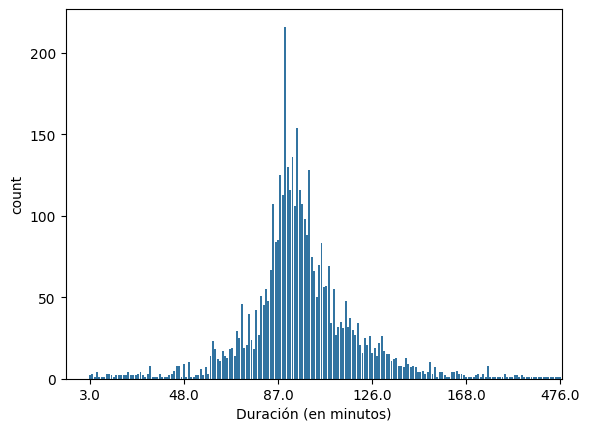

Mediana: 95.0
Media: 97.01825942613232
Moda: 90.0
desviacion std: 25.865637687941113


In [3]:
duracion=df_EDA['runtime'].dropna()
duracion=duracion[duracion!=0]
sns.countplot(x=duracion)
# Limitar el número de ejes X a 5 y correr el eje X para que 0 sea mas visible.
plt.xlim(left=-10)
plt.xticks(ticks=plt.gca().get_xticks()[::len(plt.gca().get_xticks()) // 5])
plt.xlabel('Duración (en minutos)')
plt.show()

print('Mediana:',duracion.median())
print('Media:',duracion.mean())
print('Moda:',duracion.mode()[0])
print('desviacion std:',duracion.std())

Es muy evidente que la distribucion de la duracion obedece a una distribucion de una normal.

Limites clusters: [(np.float64(58.663306451612904), np.float64(93.16891891891892)), (np.float64(93.16891891891892), np.float64(124.4215456674473)), (np.float64(124.4215456674473), np.float64(214.21818181818182))]


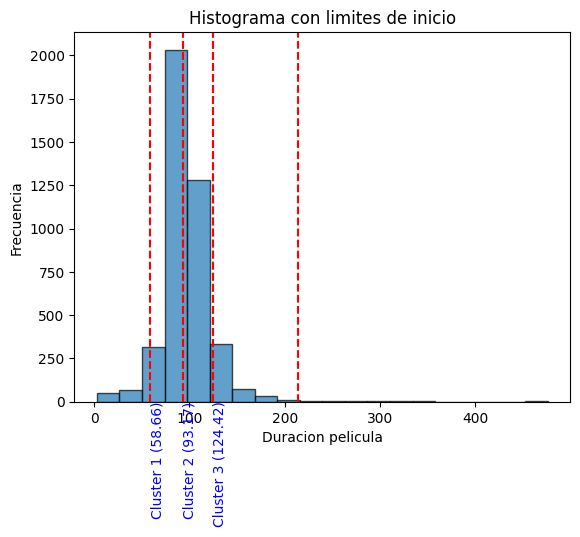

In [4]:
from sklearn.cluster import KMeans


# Assuming 'duracion' is your Series or DataFrame, and 'duracion.values' is your data for clustering
duracion_reshaped = duracion.values.reshape(-1, 1)

# Apply KMeans clustering to find 4 clusters
kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(duracion_reshaped)

# Ensure duracion is a DataFrame (if it’s a Series) and add the cluster labels as a new column
duracion = pd.DataFrame(duracion)  # Convert Series to DataFrame (if not already)
duracion['cluster'] = clusters

# Sort cluster centers to determine group limits
cluster_centers = np.sort(kmeans.cluster_centers_.flatten())  # Sort cluster centers

# Find the limits (edges) of each group (cluster) based on centroids
limites = [(cluster_centers[i], cluster_centers[i+1]) for i in range(len(cluster_centers)-1)]

# Print the group limits
print("Limites clusters:", limites)

# Plot the histogram and mark the limits of the groups
plt.hist(duracion['runtime'], bins=20, edgecolor='black', alpha=0.7)

# Correct the for-loop to unpack the correct values
for i, (limit_start, limit_end) in enumerate(limites):
    plt.axvline(limit_start, color='r', linestyle='--')
    plt.axvline(limit_end, color='r', linestyle='--')

    # Adding labels at the limits
    plt.text(limit_start, 3, f"Cluster {i+1} ({limit_start:.2f})", color='blue', rotation=90, verticalalignment='top')
 


plt.title('Histograma con limites de inicio')
plt.xlabel('Duracion pelicula')
plt.ylabel('Frecuencia')
plt.show()

Luego de realizar clustering para 3 y 5 K-vecinos el k=4 es el que mejor representa los datos. Estos son los 4 clusters- 1-57 min, 57-90min, 90-130min y 130-220min. Encontremos los pesos de los 2 mas pesados.

In [5]:
#Numero total de datos
total_datos = len(duracion)  
#La condicion del cluster 2
cluster_2 = (duracion['runtime'] >= 56.8) & (duracion['runtime'] <= 93)  
#Tamaño del cluster 2
cl_2 = len(cluster_2[cluster_2])  #
print(f"El peso del cluster 2 es de {cl_2 / total_datos * 100:.2f}%")

cluster_3=(duracion['runtime'] > 93) & (duracion['runtime'] <= 126.6)  
cl_3=len(cluster_3[cluster_3])
print(f"El peso del cluster 3 es de {cl_3 / total_datos * 100:.2f}%")
print(f"Lo que equivale que el {(cl_3 / total_datos * 100)+(cl_2 / total_datos * 100)}% de los datos estan en estos 2 clusters")

El peso del cluster 2 es de 43.92%
El peso del cluster 3 es de 44.34%
Lo que equivale que el 88.26179748636471% de los datos estan en estos 2 clusters


Existe evidencia que gran parte de los datos estan dentro del cluster 2-3, que es una franja de duracion entre 56-126 min. Es probable que esta franja muestre parte de las preferencias de los consumidores. Vamos a rellenar los datos con nulos y ceros por la media de duracion. No considero que se deba eliminar los datos poco representativos ya que si un espectador vio una pelicula corta o muy larga, esto ayudaría mucho a predecir que pelicula le gusta dado que es una caracteristicas muy particular.

In [6]:
#Reemplazar los ceros por nulos
df_EDA['runtime'] = df_EDA['runtime'].replace(0, float('nan'))

#Calcular la media
media = df_EDA['runtime'].mean()

#Reemplazar los nulos por la media
df_EDA['runtime'] = df_EDA['runtime'].fillna(media)

Una variable relevante es el año de estreno. Hay gente que le gusta las peliculas viejas y otra que le gustan las nuevas. El dia y el mes no es relevante ya que tenemos muchas peliculas a lo largo de 100 años por lo que se elimina mes y dia

In [7]:
df_EDA=df_EDA.drop(columns=["release_mes", "release_dia"])

Limites clusters: [(np.float64(1951.8312757201647), np.float64(1983.9586656997824)), (np.float64(1983.9586656997824), np.float64(2007.3007796471072)), (np.float64(2007.3007796471072), np.int64(2020))]


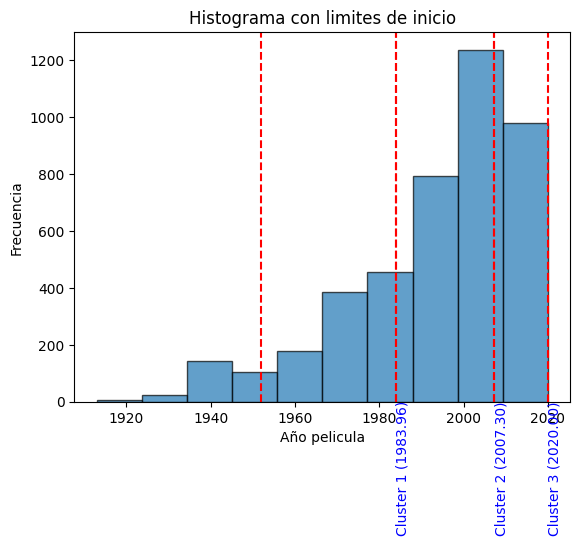

Año Pelicula mas nueva: 2020
Año Pelicula mas antigua: 1913


In [8]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_EDA is your DataFrame and 'release_año' is the column of interest
años = df_EDA["release_año"]

# Reshape the data for clustering
años_reshape = años.values.reshape(-1, 1)

# Apply KMeans clustering to find 3 clusters
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(años_reshape)

# Convert 'años' to a DataFrame (if not already) and add the cluster labels as a new column
años = pd.DataFrame(años)  # Convert Series to DataFrame (if not already)
años['cluster'] = clusters

# Sort cluster centers to determine group limits
cluster_centers = np.sort(kmeans.cluster_centers_.flatten())  # Sort cluster centers

# Find the limits (edges) of each group (cluster) based on centroids
limites = [(cluster_centers[i], cluster_centers[i+1]) for i in range(len(cluster_centers)-1)]

# Add the upper limit of the last cluster using the maximum value of the data
limites.append((cluster_centers[-1], años['release_año'].max()))

# Print the group limits
print("Limites clusters:", limites)

# Plot the histogram and mark the limits of the groups
plt.hist(años['release_año'], bins=10, edgecolor='black', alpha=0.7)

# Add vertical lines and labels for each cluster limit
for i, (limit_start, limit_end) in enumerate(limites):
    plt.axvline(limit_start, color='r', linestyle='--')
    plt.axvline(limit_end, color='r', linestyle='--')

    # Adding labels at the limits
    #plt.text(limit_start, 3, f"Cluster {i+1} ({limit_start:.2f})", color='blue', rotation=90, verticalalignment='top')
    plt.text(limit_end, 3, f"Cluster {i+1} ({limit_end:.2f})", color='blue', rotation=90, verticalalignment='top')

plt.title('Histograma con limites de inicio')
plt.xlabel('Año pelicula')
plt.ylabel('Frecuencia')
plt.show()
print('Año Pelicula mas nueva:', df_EDA['release_año'].max())
print('Año Pelicula mas antigua:', df_EDA['release_año'].min())

El dataset tiene poca peliculas clasicas. Incluso las anteriores a 1951 las ve como outlyers porque no logran crean un cluster por si misma.Los rangos de peliculas con mayores datos estan en la franja (1983-2007) y (2007-2020) con un peso total de 76%. Por esta razon vamos a eliminar todas las peliculas anteriores a 1951 porque no logran crear un cluster relevante- incluso poniendo un parametro de K-vecinos=8 esto no logra crear un cluster interesante para las peliculas anteriores a esta fecha.

In [9]:
# Se convierte a numero
df_EDA['release_año'] = pd.to_numeric(df_EDA['release_año'], errors='coerce')

# Aplicar condicion para eliminar los datos que son previos al año 1951
df_EDA['release_año'] = df_EDA['release_año'].where(df_EDA['release_año'] >= 1951, np.nan)

In [10]:
#Numero total de datos
total_datos = len(años)  
#La condicion del cluster 2
cluster_2 = (df_EDA["release_año"] >= 1983) & (df_EDA["release_año"] <= 2007)  
#Tamaño del cluster 2
cl_2 = len(cluster_2[cluster_2])  #
print(f"El peso del cluster 2 es de {cl_2 / total_datos * 100:.2f}%")

cluster_3=(df_EDA["release_año"] > 2007) & (df_EDA["release_año"] <= 2020)  
cl_3=len(cluster_3[cluster_3])
print(f"El peso del cluster 3 es de {cl_3 / total_datos * 100:.2f}%")
print(f"Lo que equivale que el {(cl_3 / total_datos * 100)+(cl_2 / total_datos * 100)}% de los datos estan en estos 2 clusters")

El peso del cluster 2 es de 46.54%
El peso del cluster 3 es de 29.50%
Lo que equivale que el 76.03440260344026% de los datos estan en estos 2 clusters


Cada vez los clusters se reducen en tiempo y su frecuencia es mas alta- es decir que las preferencias cambian cada vez mas rápido.

Exploremos las variables vote_count, popularity y vote_average...

In [11]:
df_EDA[['vote_count', 'popularity',"vote_average"]].describe()

,vote_count,popularity,vote_average
count,4302.000000,4302.000000,4302.000000
mean,417.577406,6.359909,5.879405
std,1122.605513,13.507659,1.295468
min,0.000000,0.000001,0.000000
25%,12.000000,1.304243,5.300000
50%,38.000000,3.875680,6.100000
75%,227.000000,8.496689,6.700000
max,12269.000000,547.488298,10.000000


In [12]:
from sklearn.preprocessing import StandardScaler # Importamos la libreria para escalar los datos
X=df_EDA["vote_count"]
X = X.values.reshape(-1, 1)
st_x=StandardScaler() 
vote_count_escala=st_x.fit_transform(X) 
df_EDA["vote_count_escalado"]=vote_count_escala

C:\Users\param\AppData\Local\Temp\ipykernel_12824\1972479644.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")


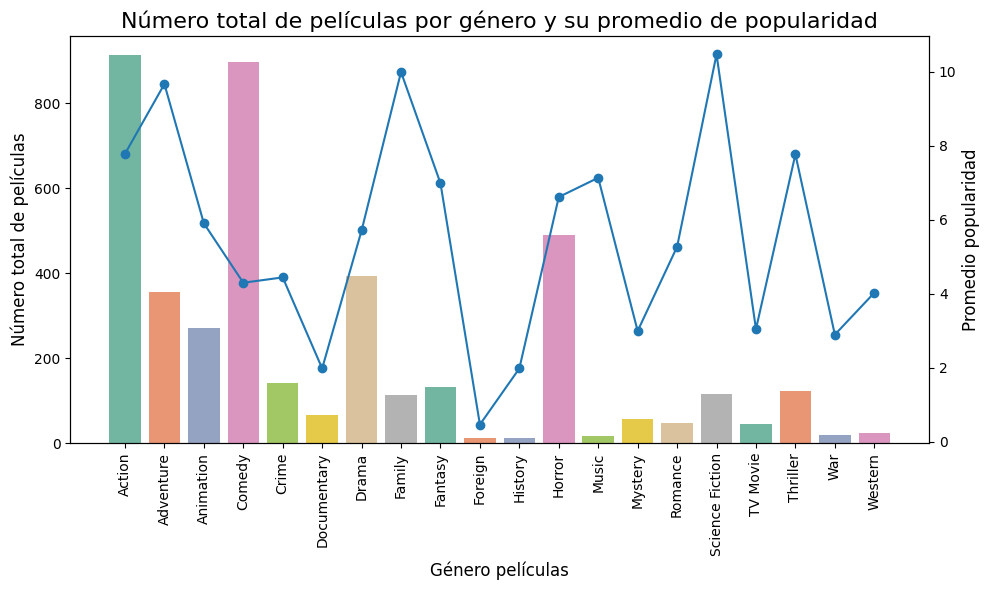

In [13]:
# Group by 'gender', count the number of movies, and calculate the average popularity
grouped_df = df_EDA.groupby('genero').agg(
    movie_count=('genero', 'size'),  # Count of movies per genre
    avg_popularity=('popularity', 'mean')  # Average popularity per genre
).reset_index()

# Set up the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot movie count (Gender Histogram)
sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")
ax1.set_title('Número total de películas por género y su promedio de popularidad', fontsize=16)
ax1.set_xlabel('Género películas', fontsize=12)
ax1.set_ylabel('Número total de películas', fontsize=12)
plt.xticks(rotation=90)
# Create a second axis for the line graph
ax2 = ax1.twinx()

# Plot average popularity (Line graph)
ax2.plot(grouped_df['genero'], grouped_df['avg_popularity'], color='tab:blue', marker='o', label='Promedio popularidad')
ax2.set_ylabel('Promedio popularidad', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

Los que tienen mejor pouplaridad son Aventura, Family y Science Fiction. El genero que más hay peliculas es Accion, Comedia y Horror. Curiosamente comedia es un genero con mucha produccion pero con baja calificacion de la popularidad... es decir hay muchas peliculas pero son poco populares. Por otra parte, el genero Family y el genero Science Fiction, tienen pocas peliculas pero con una popularidad altisima (un ejemplo puede ser Star Wars- hay pocas peliculas de ese estilo y son muy populares a nivel global). El genero Music pasa algo similar pero en menor grado. La popularidad mas baja es de las peliculas son las extranjeras, de historia o documentales.. con estos 3 generos la produccion es baja y de poca popularidad... Una conclusion general es que una alta produccion de peliculas de un genero no lleva a una alta popularidad- no tienen correlación. Ahora analicemos genero con vote average:

C:\Users\param\AppData\Local\Temp\ipykernel_12824\3253441641.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")


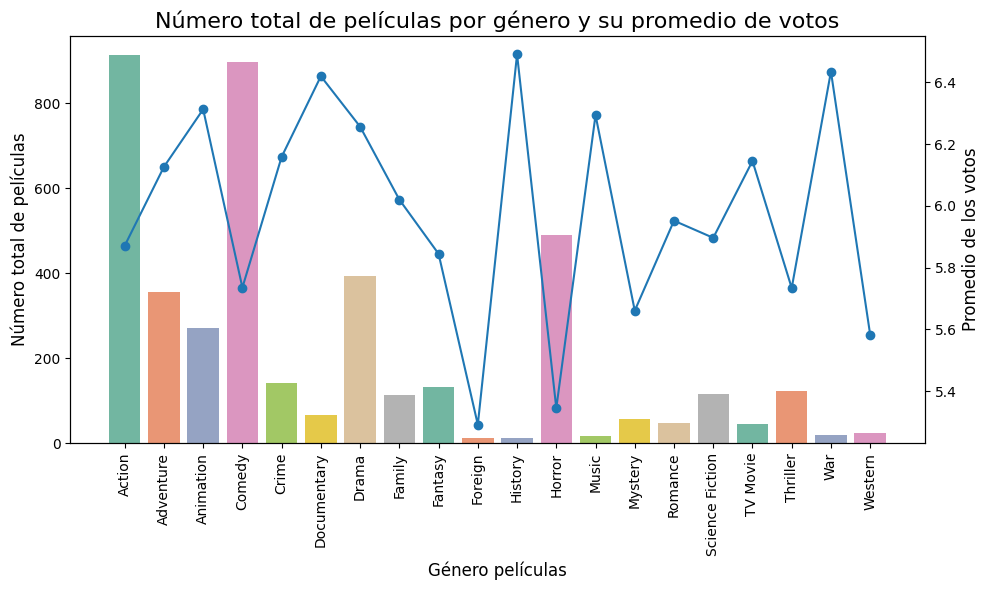

In [14]:
# Group by 'gender', count the number of movies, and calculate the average popularity
grouped_df = df_EDA.groupby('genero').agg(
    movie_count=('genero', 'size'),  # Count of movies per genre
    avg_popularity=('vote_average', 'mean')  # Average popularity per genre
).reset_index()

# Set up the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot movie count (Gender Histogram)
sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")
ax1.set_title('Número total de películas por género y su promedio de votos', fontsize=16)
ax1.set_xlabel('Género películas', fontsize=12)
ax1.set_ylabel('Número total de películas', fontsize=12)
plt.xticks(rotation=90)
# Create a second axis for the line graph
ax2 = ax1.twinx()

# Plot average popularity (Line graph)
ax2.plot(grouped_df['genero'], grouped_df['avg_popularity'], color='tab:blue', marker='o', label='Average Popularity')
ax2.set_ylabel('Promedio de los votos', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

Los resultados son muy distintos. De hecho las peliculas poco populares, no tiene que ver mucho con la calificacion de los espectadores. Un claro ejemplo es que los documentales, las peliculas de historia, musica y de guerra, que son generos poco populares, tiene muy buena calificacion entre los espectadores. Las peliculas de horror, que son de alta produccion, tiene bajos niveles de aprobacion por parte del publico- "muchas películas de horror y de mala calidad". Esto tambien aplica para las peliculas de Accion y Comedia, que sumando al genero Horror son alrededor de la mitad de todo el dataset y a la vez con un promedio menor al 5.8 de votos. Este cuadro muestra que hay mucha produccion de peliculas que no tienen una alta calificacion- ¿se producen peliculas para pasar el rato o por un verdadero gusto al septimo arte? Analicemos si gran parte de la produccion viene de Holywood (USA) y como esto afecta su popularidad y promedio de votos

C:\Users\param\AppData\Local\Temp\ipykernel_12824\3215732477.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pais_origen', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")


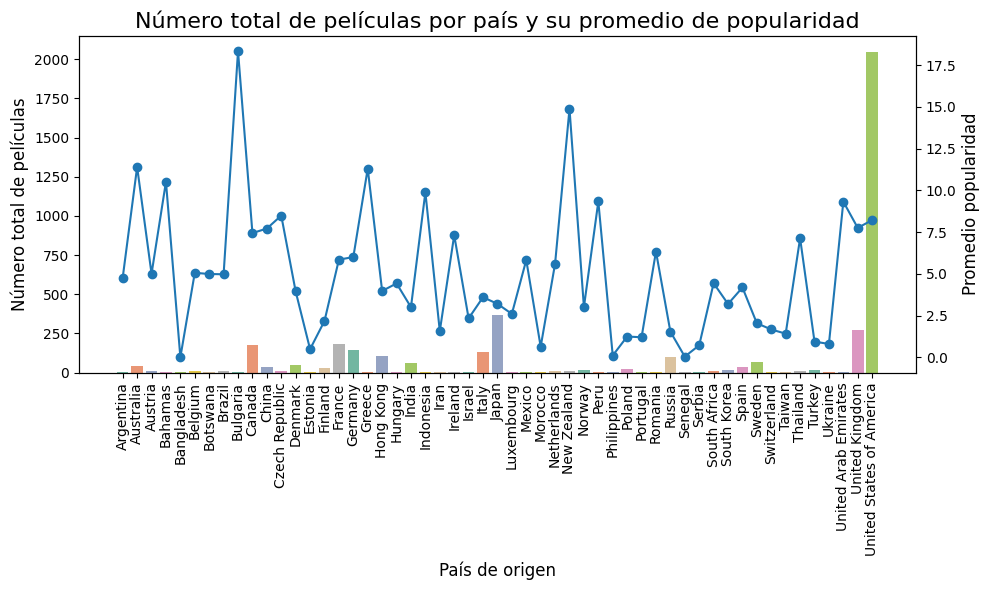

In [15]:
# Agrupar por genero, contar el numero de peliculas y calcular la media de popularidad
grouped_df = df_EDA.groupby('pais_origen').agg(
    movie_count=('pais_origen', 'size'),  # Count of movies per genre
    avg_popularity=('popularity', 'mean')  # Average popularity per genre
).reset_index()

# Set up the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot movie count (Gender Histogram)
sns.barplot(x='pais_origen', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")
ax1.set_title('Número total de películas por país y su promedio de popularidad', fontsize=16)
ax1.set_xlabel('País de origen', fontsize=12)
ax1.set_ylabel('Número total de películas', fontsize=12)
plt.xticks(rotation=90)
# Create a second axis for the line graph
ax2 = ax1.twinx()

# Plot average popularity (Line graph)
ax2.plot(grouped_df['pais_origen'], grouped_df['avg_popularity'], color='tab:blue', marker='o', label='Average Popularity')
ax2.set_ylabel('Promedio popularidad', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

En mi primera intuicion, consideré que las películas más populares son las que vienen de USA por su capacidad mediatica y por tener multiples canales de distribucion de peliculas. No obstante, esto no resultó cierto porque hay paises con mejor puntuacion de popularidad a pesar de ser pequeños paises productores de peliculas. En nuestro diccionario de movie dataset aparece que la popularidad es- "Puntaje de popularidad de la película, asignado por TMDB (TheMoviesDataBase)", es decir esa metrica como es calculada es desconocida por nosotros. El país con las peliculas mas populares es Bulgaria y el menos popular es Bangladesh. Estados Unidos que es el vasto productor de peliculas, esta más arriba que el promedio... La grafica muestra una alta volatilidad entre paises de acuerdo a su popularidad y que su produccion es bajisima en comparacion a USA. Ahora, serán estos resultados igual de acuerdo al promedio de votos??

In [16]:
pais_mayor_popularidad = grouped_df.loc[grouped_df['avg_popularity'].idxmax()]
print(pais_mayor_popularidad)

pais_origen        Bulgaria
movie_count               6
avg_popularity    18.342209
Name: 8, dtype: object


In [17]:
pais_menor_popularidad = grouped_df.loc[grouped_df['avg_popularity'].idxmin()]
print(pais_menor_popularidad)

pais_origen       Bangladesh
movie_count                1
avg_popularity      0.003013
Name: 4, dtype: object


C:\Users\param\AppData\Local\Temp\ipykernel_12824\2822473271.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pais_origen', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")


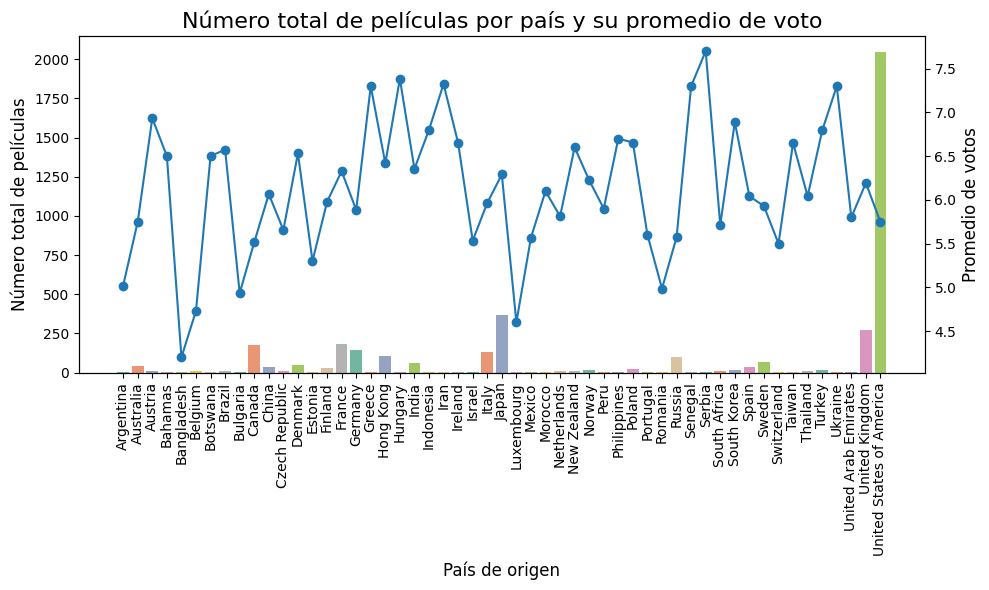

In [18]:
# Group by 'gender', count the number of movies, and calculate the average popularity
grouped_df = df_EDA.groupby('pais_origen').agg(
    movie_count=('pais_origen', 'size'),  # Count of movies per genre
    avg_vote=('vote_average', 'mean') 
).reset_index()

# Set up the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot movie count (Gender Histogram)
sns.barplot(x='pais_origen', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")
ax1.set_title('Número total de películas por país y su promedio de voto', fontsize=16)
ax1.set_xlabel('País de origen', fontsize=12)
ax1.set_ylabel('Número total de películas', fontsize=12)
plt.xticks(rotation=90)
# Create a second axis for the line graph
ax2 = ax1.twinx()

# Plot average popularity (Line graph)
ax2.plot(grouped_df['pais_origen'], grouped_df['avg_vote'], color='tab:blue', marker='o', label='Average Popularity')
ax2.set_ylabel('Promedio de votos', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [19]:
promedio_popularidad=df_EDA["vote_average"].mean()
print(promedio_popularidad)

5.8794049279404925


In [20]:
df_usa = df_EDA[df_EDA['pais_origen'] == 'United States of America']
promedio_usa = df_usa['vote_average'].mean()
print(promedio_usa)

5.7449926722032245


In [21]:
df_japan = df_EDA[df_EDA['pais_origen'] == 'Japan']
promedio_japan = df_japan['vote_average'].mean()
print(promedio_japan)

6.289972899728998


In [22]:
df_uk = df_EDA[df_EDA['pais_origen'] == 'United Kingdom']
promedio_uk = df_uk['vote_average'].mean()
print(promedio_uk)

6.192727272727272


In [23]:
pais_mejor_promedio_votos= grouped_df.loc[grouped_df['avg_vote'].idxmax()]
print(pais_mejor_promedio_votos)

pais_origen    Serbia
movie_count         1
avg_vote          7.7
Name: 40, dtype: object


El promedio de votos mejora mucho la percepcion de las peliculas fuera de USA ya que la mayoria estan mejor posicionadas que USA. De hecho, USA está más bajo que la media. De alguna manera, aunque USA lidera la producción de películas, no lidera en la calidad de ellas ya que su voto promedio es inferior a la media del dataset. Serbia que lidera el escalón apenas tiene una pelícla producida. No obstante Japon y United Kingdom, que son los dos paises que siguen a USA en producción, tienen mejor calificación que USA.

C:\Users\param\AppData\Local\Temp\ipykernel_12824\4049574819.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")


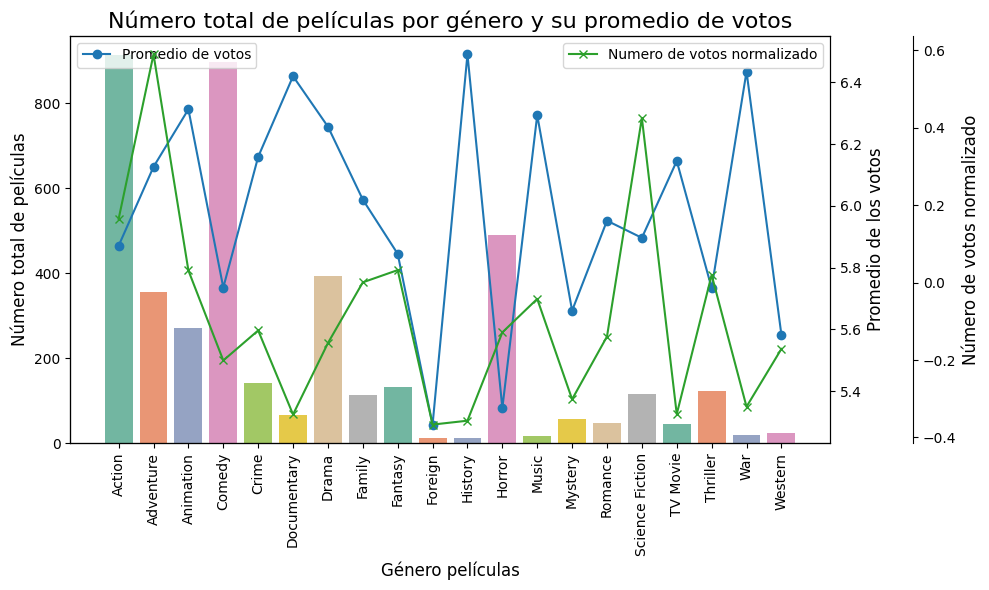

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped_df = df_EDA.groupby('genero').agg(
    movie_count=('genero', 'size'),  # Count of movies per genre
    avg_vote=('vote_average', 'mean'),  # Average popularity per genre
    numero_votos=('vote_count_escalado', 'mean')  # Replace 'another_column' with the column you want to plot
).reset_index()

# Set up the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot movie count (Genre Histogram)
sns.barplot(x='genero', y='movie_count', data=grouped_df, ax=ax1, palette="Set2")
ax1.set_title('Número total de películas por género y su promedio de votos', fontsize=16)
ax1.set_xlabel('Género películas', fontsize=12)
ax1.set_ylabel('Número total de películas', fontsize=12)
plt.xticks(rotation=90)

# Create a second axis for the line graph (average popularity)
ax2 = ax1.twinx()
ax2.plot(grouped_df['genero'], grouped_df['avg_vote'], color='tab:blue', marker='o', label='Promedio de votos')
ax2.set_ylabel('Promedio de los votos', fontsize=12)

ax2.legend(loc='upper left')

# Create a third axis for the third variable (if needed)
ax3 = ax1.twinx()

# Move ax3 slightly to the right to avoid overlap
ax3.spines['right'].set_position(('outward', 60))  # Adjust this value if needed

# Plot third variable (another line graph)
ax3.plot(grouped_df['genero'], grouped_df['numero_votos'], color='tab:green', marker='x', label='Numero de votos normalizado')
ax3.set_ylabel('Número de votos normalizado', fontsize=12)

ax3.legend(loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()

Con esta grafica se verifica que los géneros de películas de poca produccion como historia, documental, war, etc. tuvieron bajos niveles de votacion pero si alto promedio del voto. Es grave, en terminos de calidad, cuando la curva "verde" esta arriba de la "azul" ya que hubo buena cantidad de votos que no les gusto tanto la pelicula- dentro de estos casos esta Action, Horror y Science Fiction. El mas problematico es Horror por ser el minimo en la escala de promedio de votos. 

Otra variable relevante es analizar el efecto de las variables financieras sobre la popularidad, cantidad de votos o vote average...

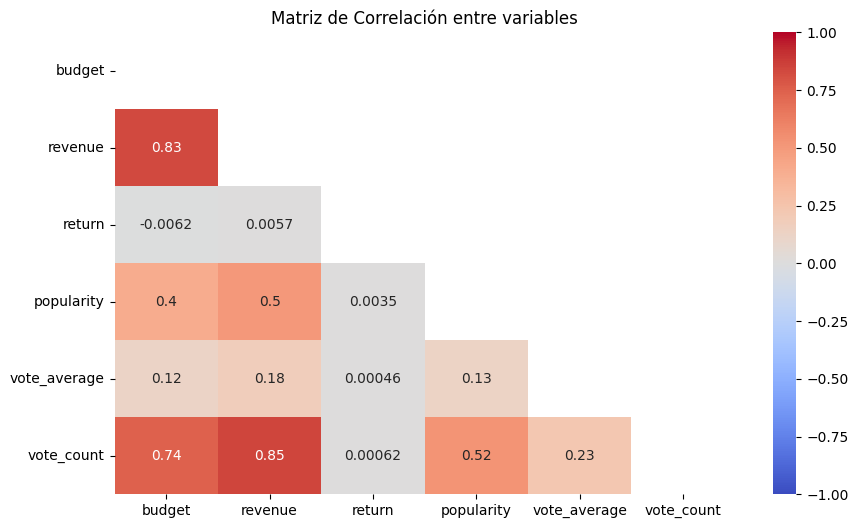

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selecciona variables
df_corr = df_EDA[['budget', 'revenue', 'return', 'popularity', 'vote_average', 'vote_count']]

# Calcula la matriz de correlación
corr = df_corr.corr()

# Crea una grafica
fig, ax = plt.subplots(figsize=(10, 6))

# Crea un mapa de calor para visualizar la correlación
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación entre variables')

plt.show()

Hay una alta correlacion positiva entre Budget y Revenue- es decir en lo que gasta y el ingreso. De igual manera hay una alta correlación entre el budget (presupuesto) y la cantidad de votos. De igual manera hay una correlacion positiva entre los ingresos y el numero de votos. ¿Si normalizamos todas las variables se podria encontrar otro tipo de correlaciones?

In [26]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Se crea funcion para limpiar y rellenar con media
def clean_and_scale(column_name, df):
    # Mirar si hay numeros infitos y reemplazar con nulos
    df[column_name] = df[column_name].replace([np.inf, -np.inf], np.nan)  
    df[column_name] = df[column_name].fillna(df[column_name].mean())  # Reemplazar nulos con la media.
    
    # Escalar la columna
    X = df[column_name].values.reshape(-1, 1)
    st_x = StandardScaler()
    return st_x.fit_transform(X)

# Aplicar la funcion a cada columna
df_EDA["vote_count_escalado"] = clean_and_scale("vote_count", df_EDA)
df_EDA["budget_escalado"] = clean_and_scale("budget", df_EDA)
df_EDA["revenue_escalado"] = clean_and_scale("revenue", df_EDA)
df_EDA["return_escalado"] = clean_and_scale("return", df_EDA)
df_EDA["popularity_escalado"] = clean_and_scale("popularity", df_EDA)
df_EDA["vote_average_escalado"] = clean_and_scale("vote_average", df_EDA)

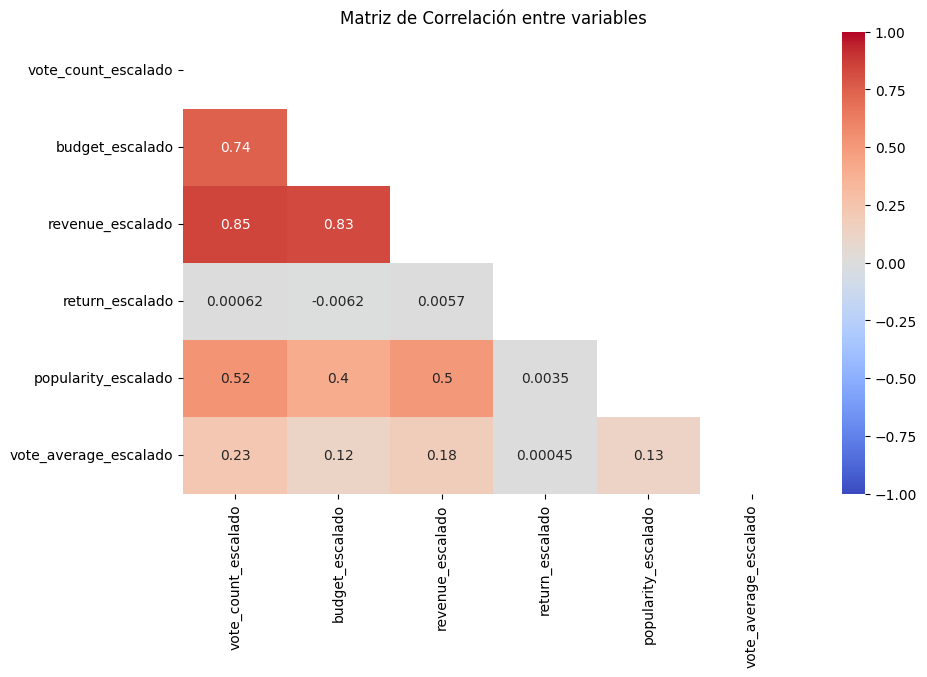

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selecciona variables
df_corr = df_EDA[['vote_count_escalado', 'budget_escalado', 'revenue_escalado', 'return_escalado', 'popularity_escalado', 'vote_average_escalado']]

# Calcula la matriz de correlación
corr = df_corr.corr()

# Crea una grafica
fig, ax = plt.subplots(figsize=(10, 6))

# Crea un mapa de calor para visualizar la correlación
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlación entre variables')

plt.show()

El resultado es el mismo cuando se escalan las variables. Por lo tanto se eliminan las variables creadas. RETURN no tiene efecto con la popularidad o vote_Average, por lo tanto se elimina de igual manera.

In [28]:
df_EDA=df_EDA.drop(columns=['vote_count_escalado', 'budget_escalado', 'revenue_escalado', 'return_escalado', 'popularity_escalado', 'vote_average_escalado',"return"])

Rectifiquemos que todas las variables no tengan nulos o ceros. 

In [29]:
print(df_EDA.isnull().sum())

budget                  0
original_language       0
overview               54
popularity              0
revenue                 0
runtime                 0
tagline              1792
title                   0
vote_average            0
vote_count              0
nombre_actor            0
nombre_director         0
titulo_pelicula         0
nombre_productora     572
genero                 61
pais_origen           225
release_año           215
dtype: int64


En vez de eliminar registros dado los nulos de productora, lo que se va hacer es eliminar ese atributo. Esto se debe a que el pais de origen representa mas que suficiente el peso de las productoras ya que la mitad del dataset viene de USA- productoras grandes y famosas a nivel global. Es probable que si eliminamos esos registros, las pequeñas productoras de paises con poca produccion de peliculas se irian y debilitarían el modelo. Teniendo en cuenta lo anterior, tambien se elimino la columna "tag line" por tener muchos nulos. Por otra parte, para los nulos de pais de origen se va a poner United States of America dado que es el promedio de los datos. Por otra parte, para los nulos que estan en genero, se va a rellenar con "Action" dado que son pocos los nulos. Por último se eliminan los valores nulos de nombre_actor, review y nombre_director (ya que no tiene sentido de rellenar esto con moda u otra medida central). Release año se rellena con el promedio...

In [30]:
#Se elimina la columna nombre_productora por tener muchos nulos y porque ya sabemos que USA tiene mucho peso en la produccion de peliculas
df_EDA=df_EDA.drop(columns=['nombre_productora',"tagline"])
#Rellenar valores nulos con los nombres mas comunes
df_EDA['pais_origen'] = df_EDA['pais_origen'].fillna('United States of America')
df_EDA['genero'] = df_EDA['genero'].fillna('Action')
#Rellenar el año con el promedio de año
promedio_año=int(df_EDA["release_año"].mean())
print(promedio_año)
df_EDA['release_año'] = df_EDA['release_año'].fillna(1996)
#Eliminamos los registros que no tengan actor ni director
df_EDA_sinNan= df_EDA.dropna(subset=['nombre_actor',"nombre_director","overview"])



1996


In [31]:
print(df_EDA_sinNan.isnull().sum())

budget               0
original_language    0
overview             0
popularity           0
revenue              0
runtime              0
title                0
vote_average         0
vote_count           0
nombre_actor         0
nombre_director      0
titulo_pelicula      0
genero               0
pais_origen          0
release_año          0
dtype: int64


In [33]:
print((df_EDA_sinNan == 0).sum())

budget               2696
original_language       0
overview                0
popularity              0
revenue              2794
runtime                 0
title                   0
vote_average           54
vote_count             49
nombre_actor            0
nombre_director         0
titulo_pelicula         0
genero                  0
pais_origen             0
release_año             0
dtype: int64


In [34]:
# Encontramos promedio de todas las variables
promedio_budget=df_EDA_sinNan['budget'][df_EDA_sinNan['budget'] != 0].mean()
promedio_revenue=df_EDA_sinNan["revenue"][df_EDA_sinNan["revenue"]!=0].mean()
promedio_runtime=df_EDA_sinNan["runtime"][df_EDA_sinNan["runtime"]!=0].mean()
promedio_vote_average=df_EDA_sinNan["vote_average"][df_EDA_sinNan["vote_average"]!=0].mean()
promedio_vote_count=df_EDA_sinNan["vote_count"][df_EDA_sinNan["vote_count"]!=0].mean()


# Remplazar los ceros con el promedio
df_EDA_sinNan.loc[df_EDA_sinNan['budget'] == 0, 'budget'] = promedio_budget
df_EDA_sinNan.loc[df_EDA_sinNan['revenue'] == 0, 'revenue'] = promedio_revenue
df_EDA_sinNan.loc[df_EDA_sinNan['runtime'] == 0, 'runtime'] = promedio_runtime
df_EDA_sinNan.loc[df_EDA_sinNan['vote_average'] == 0, 'vote_average'] = promedio_vote_average
df_EDA_sinNan.loc[df_EDA_sinNan['vote_count'] == 0, 'vote_count'] = promedio_vote_count

In [35]:
print((df_EDA_sinNan == 0).sum())

budget               0
original_language    0
overview             0
popularity           0
revenue              0
runtime              0
title                0
vote_average         0
vote_count           0
nombre_actor         0
nombre_director      0
titulo_pelicula      0
genero               0
pais_origen          0
release_año          0
dtype: int64


In [36]:
print(df_EDA_sinNan.dtypes)

budget               float64
original_language     object
overview              object
popularity           float64
revenue              float64
runtime              float64
title                 object
vote_average         float64
vote_count           float64
nombre_actor          object
nombre_director       object
titulo_pelicula       object
genero                object
pais_origen           object
release_año          float64
dtype: object


Los datos estan listos para ser enviados a nuestro modelo-

In [39]:
import os

tabla_modelo=df_EDA_sinNan
modelo="df_modelo"

file_path_modelo=r"C:\Users\param\OneDrive\Escritorio\Programacion\Soy Henry\Proyecto individual 1\MODELO"

path_modelo=os.path.join(file_path_modelo,modelo)
tabla_modelo.to_csv(path_modelo,index=False)